In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_parquet("results.parquet")

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 308408 entries, 0 to 308407
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   year        305807 non-null  float64
 1   type        305807 non-null  str    
 2   discipline  308407 non-null  str    
 3   event       308408 non-null  str    
 4   as          308408 non-null  str    
 5   athlete_id  308408 non-null  int64  
 6   noc         308407 non-null  str    
 7   team        121714 non-null  str    
 8   place       283193 non-null  float64
 9   tied        308408 non-null  bool   
 10  medal       44139 non-null   str    
dtypes: bool(1), float64(2), int64(1), str(7)
memory usage: 46.0 MB


In [4]:
data.shape

(308408, 11)

In [5]:
data.columns

Index(['year', 'type', 'discipline', 'event', 'as', 'athlete_id', 'noc',
       'team', 'place', 'tied', 'medal'],
      dtype='str')

In [6]:
data.head()

,year,type,discipline,event,as,athlete_id,noc,team,place,tied,medal
0,1912.0,Summer,Tennis,"Singles, Men (Olympic)",Jean-François Blanchy,1,FRA,NaN,17.0,True,NaN
1,1912.0,Summer,Tennis,"Doubles, Men (Olympic)",Jean-François Blanchy,1,FRA,Jean Montariol,NaN,False,NaN
2,1920.0,Summer,Tennis,"Singles, Men (Olympic)",Jean-François Blanchy,1,FRA,NaN,32.0,True,NaN
3,1920.0,Summer,Tennis,"Doubles, Mixed (Olympic)",Jean-François Blanchy,1,FRA,Jeanne Vaussard,8.0,True,NaN
4,1920.0,Summer,Tennis,"Doubles, Men (Olympic)",Jean-François Blanchy,1,FRA,Jacques Brugnon,4.0,False,NaN


In [7]:
data.isna().sum()

year            2601
type            2601
discipline         1
event              0
as                 0
athlete_id         0
noc                1
team          186694
place          25215
tied               0
medal         264269
dtype: int64

In [8]:
data_new = data.copy()

In [9]:
data_new.head()

,year,type,discipline,event,as,athlete_id,noc,team,place,tied,medal
0,1912.0,Summer,Tennis,"Singles, Men (Olympic)",Jean-François Blanchy,1,FRA,NaN,17.0,True,NaN
1,1912.0,Summer,Tennis,"Doubles, Men (Olympic)",Jean-François Blanchy,1,FRA,Jean Montariol,NaN,False,NaN
2,1920.0,Summer,Tennis,"Singles, Men (Olympic)",Jean-François Blanchy,1,FRA,NaN,32.0,True,NaN
3,1920.0,Summer,Tennis,"Doubles, Mixed (Olympic)",Jean-François Blanchy,1,FRA,Jeanne Vaussard,8.0,True,NaN
4,1920.0,Summer,Tennis,"Doubles, Men (Olympic)",Jean-François Blanchy,1,FRA,Jacques Brugnon,4.0,False,NaN


In [10]:
data_new = data_new.astype({"year": "Int64"})
data_new = data_new.astype({"place":"Int64"})
data_new["type"] = data_new["type"].fillna('Unknown').astype("string")
data_new["discipline"] = data_new["discipline"].fillna("Unknown").astype("string")
data_new["team"] = data_new["team"].fillna("No_Equipo").astype("string")
data_new["medal"] = data_new["medal"].fillna("Ninguna").astype("string")
data_new["noc"] = data_new["noc"].fillna("No_NOC").astype("string")

In [11]:
data_new.info()

<class 'pandas.DataFrame'>
RangeIndex: 308408 entries, 0 to 308407
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   year        305807 non-null  Int64 
 1   type        308408 non-null  string
 2   discipline  308408 non-null  string
 3   event       308408 non-null  str   
 4   as          308408 non-null  str   
 5   athlete_id  308408 non-null  int64 
 6   noc         308408 non-null  string
 7   team        308408 non-null  string
 8   place       283193 non-null  Int64 
 9   tied        308408 non-null  bool  
 10  medal       308408 non-null  string
dtypes: Int64(2), bool(1), int64(1), str(2), string(5)
memory usage: 49.8 MB


In [12]:
data_new.isna().sum()

year           2601
type              0
discipline        0
event             0
as                0
athlete_id        0
noc               0
team              0
place         25215
tied              0
medal             0
dtype: int64

In [13]:
data_new['type'] = data_new['type'].str.strip()
data_new['discipline'] = data_new['discipline'].str.strip()
data_new['event'] = data_new['event'].str.strip()
data_new['as'] = data_new['as'].str.strip()
data_new['noc'] = data_new['noc'].str.strip()
data_new['team'] = data_new['team'].str.strip()
data_new['medal'] = data_new['medal'].str.strip()

In [14]:
data_new.head()

,year,type,discipline,event,as,athlete_id,noc,team,place,tied,medal
0,1912,Summer,Tennis,"Singles, Men (Olympic)",Jean-François Blanchy,1,FRA,No_Equipo,17,True,Ninguna
1,1912,Summer,Tennis,"Doubles, Men (Olympic)",Jean-François Blanchy,1,FRA,Jean Montariol,<NA>,False,Ninguna
2,1920,Summer,Tennis,"Singles, Men (Olympic)",Jean-François Blanchy,1,FRA,No_Equipo,32,True,Ninguna
3,1920,Summer,Tennis,"Doubles, Mixed (Olympic)",Jean-François Blanchy,1,FRA,Jeanne Vaussard,8,True,Ninguna
4,1920,Summer,Tennis,"Doubles, Men (Olympic)",Jean-François Blanchy,1,FRA,Jacques Brugnon,4,False,Ninguna


In [15]:
import unicodedata  

def quitar_tildes(texto):   
    if isinstance(texto, str):
        texto = unicodedata.normalize("NFKD", texto)
        return "".join(c for c in texto if not unicodedata.combining(c))
    return texto

In [16]:
cols = ["discipline", "event", "as", "team"]

for c in cols:
    data_new[c] = data_new[c].astype("string").str.strip().map(quitar_tildes)

In [17]:
data_new

,year,type,discipline,event,as,athlete_id,noc,team,place,tied,medal
0,1912,Summer,Tennis,"Singles, Men (Olympic)",Jean-Francois Blanchy,1,FRA,No_Equipo,17,True,Ninguna
1,1912,Summer,Tennis,"Doubles, Men (Olympic)",Jean-Francois Blanchy,1,FRA,Jean Montariol,<NA>,False,Ninguna
2,1920,Summer,Tennis,"Singles, Men (Olympic)",Jean-Francois Blanchy,1,FRA,No_Equipo,32,True,Ninguna
3,1920,Summer,Tennis,"Doubles, Mixed (Olympic)",Jean-Francois Blanchy,1,FRA,Jeanne Vaussard,8,True,Ninguna
4,1920,Summer,Tennis,"Doubles, Men (Olympic)",Jean-Francois Blanchy,1,FRA,Jacques Brugnon,4,False,Ninguna
...,...,...,...,...,...,...,...,...,...,...,...
308403,2022,Winter,Luge,"Singles, Men (Olympic)",Marian Skupek,148983,SVK,No_Equipo,26,False,Ninguna
308404,2022,Winter,Alpine Skiing (Skiing),"Slalom, Women (Olympic)",Elsa Fermback,148984,SWE,No_Equipo,28,False,Ninguna
308405,2022,Winter,Alpine Skiing (Skiing),"Team, Mixed (Olympic)",Hilma Lovblom,148985,SWE,Sweden,13,False,Ninguna
308406,2022,Winter,Alpine Skiing (Skiing),"Giant Slalom, Women (Olympic)",Hilma Lovblom,148985,SWE,No_Equipo,<NA>,False,Ninguna


In [18]:
data_new.info()

<class 'pandas.DataFrame'>
RangeIndex: 308408 entries, 0 to 308407
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   year        305807 non-null  Int64 
 1   type        308408 non-null  string
 2   discipline  308408 non-null  str   
 3   event       308408 non-null  str   
 4   as          308408 non-null  str   
 5   athlete_id  308408 non-null  int64 
 6   noc         308408 non-null  string
 7   team        308408 non-null  str   
 8   place       283193 non-null  Int64 
 9   tied        308408 non-null  bool  
 10  medal       308408 non-null  string
dtypes: Int64(2), bool(1), int64(1), str(4), string(3)
memory usage: 49.9 MB


In [19]:
data_new = data_new.rename(columns={'year': 'Año'}) 
data_new = data_new.rename(columns={'type': 'Juegos'}) 
data_new = data_new.rename(columns={'discipline': 'Deporte'}) 
data_new = data_new.rename(columns={'event': 'Categoria'}) 
data_new = data_new.rename(columns={'as': 'Atleta'}) 
data_new = data_new.rename(columns={'athlete_id': 'ID_Atleta'}) 
data_new = data_new.rename(columns={'noc': 'NOC'}) 
data_new = data_new.rename(columns={'team': 'Equipo'}) 
data_new = data_new.rename(columns={'place': 'Posicion'}) 
data_new = data_new.rename(columns={'tied': 'Empatado'}) 
data_new = data_new.rename(columns={'medal': 'Medalla'}) 

In [20]:
data_new['Juegos'] = data_new['Juegos'].str.replace("Summer", "Verano", regex=False)    
data_new['Juegos'] = data_new['Juegos'].str.replace("Winter", "Invierno", regex=False)

In [21]:
data_new.head()

,Año,Juegos,Deporte,Categoria,Atleta,ID_Atleta,NOC,Equipo,Posicion,Empatado,Medalla
0,1912,Verano,Tennis,"Singles, Men (Olympic)",Jean-Francois Blanchy,1,FRA,No_Equipo,17,True,Ninguna
1,1912,Verano,Tennis,"Doubles, Men (Olympic)",Jean-Francois Blanchy,1,FRA,Jean Montariol,<NA>,False,Ninguna
2,1920,Verano,Tennis,"Singles, Men (Olympic)",Jean-Francois Blanchy,1,FRA,No_Equipo,32,True,Ninguna
3,1920,Verano,Tennis,"Doubles, Mixed (Olympic)",Jean-Francois Blanchy,1,FRA,Jeanne Vaussard,8,True,Ninguna
4,1920,Verano,Tennis,"Doubles, Men (Olympic)",Jean-Francois Blanchy,1,FRA,Jacques Brugnon,4,False,Ninguna


2. Verano vs Invierno (comparación de resultados)

In [22]:
from scipy import stats

pos_verano = data_new.loc[
    data_new["Juegos"] == "Verano", "Posicion"
].dropna()

pos_invierno = data_new.loc[
    data_new["Juegos"] == "Invierno", "Posicion"
].dropna()

resultado = stats.mannwhitneyu(
    pos_verano, pos_invierno,
    alternative="two-sided"
)

print("Estadístico:", resultado.statistic)
print("p:", resultado.pvalue)

Estadístico: 5223366221.0
p: 0.0


Se aplicó la prueba no paramétrica de Mann–Whitney U para comparar la distribución de posiciones entre los Juegos de Verano y de Invierno. El estadístico obtenido fue 𝑈=5.223.366.221 con un valor 𝑝p prácticamente nulo (𝑝≈0p≈0). Dado que 𝑝<0,05, se rechaza la hipótesis de igualdad de distribuciones: las posiciones alcanzadas en Juegos de Verano e Invierno difieren de forma estadísticamente significativa.

In [23]:
resumen_juegos = (
    data_new.groupby("Juegos")["Posicion"]
            .agg(
                Observaciones="count",
                Media="mean",
                Mediana="median",
                Desviacion="std"
            )
)

print(resumen_juegos)

          Observaciones      Media  Mediana  Desviacion
Juegos                                                 
Invierno          58296  19.073761     13.0   17.722132
Unknown            1674   7.917563      4.0    8.464144
Verano           223223  15.388253      8.0    19.69247


Las estadísticas descriptivas por tipo de Juegos muestran que los resultados en Juegos de Verano tienden a ser mejores que en Juegos de Invierno. En Verano, la posición media es 15,39 y la mediana 8, mientras que en Invierno la posición media asciende a 19,07 y la mediana a 13. Dado que una posición más baja indica un mejor resultado, estos valores sugieren que los participantes alcanzan, en promedio, lugares más altos en los Juegos de Verano. La categoría Unknown presenta posiciones medias aún mejores, pero corresponde a un número reducido de registros a casos con información incompleta, por lo que se interpreta con cautela. Estos hallazgos son consistentes con la prueba de Mann–Whitney U, que indicó diferencias estadísticamente significativas entre las distribuciones de posiciones de Verano e Invierno.

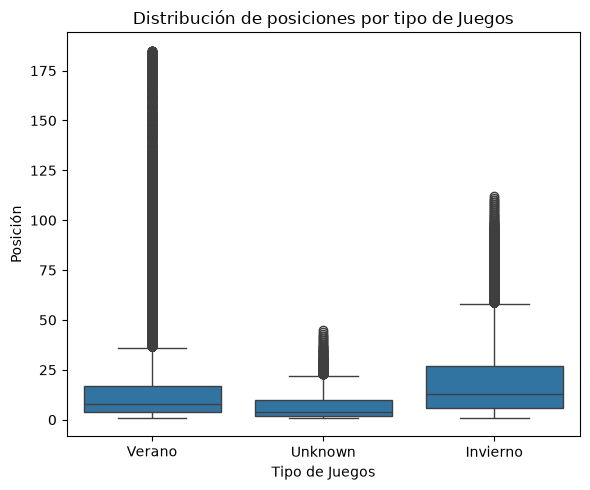

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

sns.boxplot(
    data=data_new,
    x="Juegos",
    y="Posicion"
)

plt.title("Distribución de posiciones por tipo de Juegos")
plt.xlabel("Tipo de Juegos")
plt.ylabel("Posición")
plt.tight_layout()
plt.show()

El diagrama de caja muestra que los Juegos de Verano presentan una distribución de posiciones mejor que los Juegos de Invierno, ya que su mediana y su rango intercuartílico se sitúan en valores más bajos. El grupo Unknown aparece con posiciones aún mejores, aunque debe interpretarse con cautela debido a su reducido número de registros. La presencia de numerosos valores atípicos en Verano y de una dispersión más amplia en Invierno sugiere que, aunque Verano concentra mejores resultados, también contiene casos muy alejados del patrón central. En conjunto, la gráfica es coherente con la prueba de Mann–Whitney U y con las estadísticas descriptivas previas, confirmando diferencias significativas entre ambos tipos de Juegos.

3. Medallero por país (NOC)

In [25]:
medallero = (
    data_new.groupby(["NOC", "Medalla"])
            .size()
            .unstack(fill_value=0)
)

medallero["Total"] = medallero.sum(axis=1)
medallero_ordenado = medallero.sort_values(
    "Total",
    ascending=False
)

medallero_ordenado.head(10)

Medalla,Bronze,Gold,Ninguna,Silver,Total
NOC,,,,,
USA,1472,2717,15358,1806,21353
FRA,737,589,12267,683,14276
GBR,720,715,10971,764,13170
ITA,593,605,10365,566,12129
CAN,570,555,9829,501,11455
GER,810,817,8839,772,11238
JPN,407,358,8731,386,9882
SWE,549,517,7654,585,9305
AUS,597,380,7355,475,8807


Esto confirma una concentración fuerte del medallero en un grupo reducido de países, especialmente en USA, que está bastante por encima del resto

In [26]:
resumen_medallas = medallero["Total"].describe()
print(resumen_medallas)

count      231.000000
mean      1335.099567
std       2814.149595
min          1.000000
25%         69.500000
50%        216.000000
75%       1010.500000
max      21353.000000
Name: Total, dtype: float64


Esto sugiere una distribución muy asimétrica:

La media es muy alta respecto a la mediana.

Hay unos pocos países con muchísimas medallas.

La mayoría de países tiene un total relativamente bajo.

El máximo está muy por encima del tercer cuartil, lo que indica una cola larga hacia valores altos.

In [27]:
top_noc = medallero_ordenado.index[0]

medallas_top = medallero_ordenado.loc[top_noc, "Total"]
medallas_otros = medallero_ordenado.drop(top_noc)["Total"]

from scipy import stats

resultado = stats.ttest_1samp(
    medallas_otros,
    medallas_top
)

print("Estadístico:", resultado.statistic)
print("p:", resultado.pvalue)
print("País top:", top_noc, "Medallas:", medallas_top)

Estadístico: -122.4873592793623
p: 9.995463283383486e-211
País top: USA Medallas: 21353


Para complementar el análisis descriptivo del medallero, se comparó el total de medallas de USA con la distribución del resto de países. El resultado mostró un estadístico muy negativo(t=−122.49) y un valor p prácticamente nulo (p≈9.99×10−211). Esto indica que el número total de medallas de USA se aleja de forma extrema del comportamiento del resto de NOC. En consecuencia, USA constituye un caso claramente dominante dentro del medallero olímpico y no puede considerarse estadísticamente comparable al resto de países.

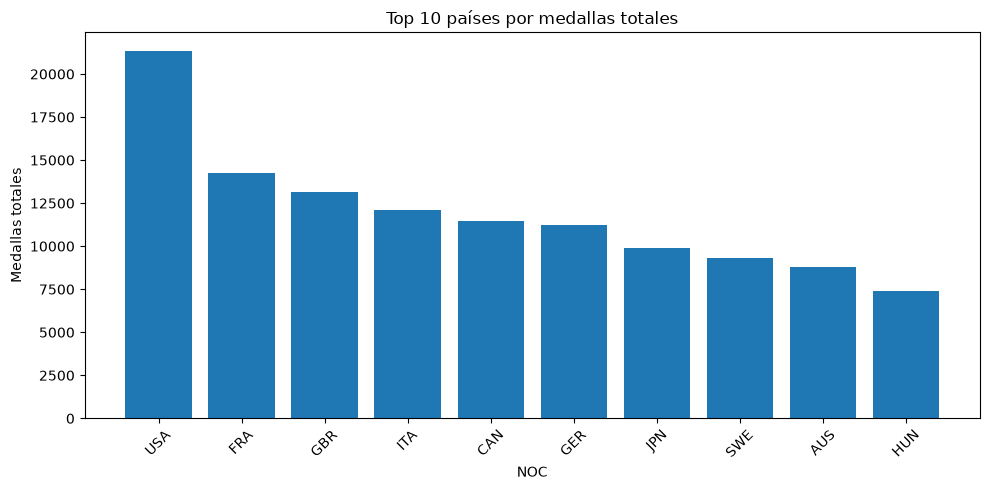

In [29]:
import matplotlib.pyplot as plt

top_n = 10

medallero_top = medallero_ordenado.head(top_n)

plt.figure(figsize=(10, 5))
plt.bar(
    medallero_top.index,
    medallero_top["Total"]
)
plt.title(f"Top {top_n} países por medallas totales")
plt.xlabel("NOC")
plt.ylabel("Medallas totales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

4. Distribución de posiciones y deportes

In [40]:
conteo_deportes = data_new["Deporte"].value_counts()
deportes_validos = conteo_deportes[conteo_deportes >= 20000].index

data_dep = data_new[
    data_new["Deporte"].isin(deportes_validos)
].copy()

grupos_deporte = [
    grupo["Posicion"].dropna().values
    for _, grupo in data_dep.groupby("Deporte")
    if len(grupo["Posicion"].dropna()) > 1
]

from scipy import stats

resultado_anova_dep = stats.f_oneway(*grupos_deporte)

print("F deportes:", resultado_anova_dep.statistic)
print("p deportes:", resultado_anova_dep.pvalue)

F deportes: 17164.50037708215
p deportes: 0.0


Para analizar la distribución de posiciones por deporte se filtraron previamente solo las disciplinas con un tamaño muestral suficiente, evitando así el problema de grupos demasiado pequeños que provocaba NaN en el ANOVA. Una vez aplicado el filtro, el contraste de un factor mostró un estadístico 𝐹=17164,50 y un valor 𝑝≈0. Dado que el valor p es prácticamente nulo, se rechaza la hipótesis nula de igualdad de medias. Esto indica que la posición media difiere de forma muy significativa entre deportes, lo que refleja contrastes claros en el nivel competitivo de las distintas disciplinas.

In [31]:
resumen_deportes = (
    data_new.groupby("Deporte")["Posicion"]
            .agg(
                Observaciones="count",
                Media="mean",
                Mediana="median",
                Desviacion="std"
            )
            .sort_values("Media")
)

print(resumen_deportes.head(10))     # deportes con mejores posiciones medias
print(resumen_deportes.tail(10))     # deportes con peores posiciones medias

                                 Observaciones     Media  Mediana  Desviacion
Deporte                                                                      
Basque pelota                                2       1.0      1.0         0.0
Motorboating                                 7       1.0      1.0         0.0
Bicycle Polo (Cycling)                       1       1.0      1.0        <NA>
Cricket                                     24       1.5      1.5    0.510754
Rugby (Rugby)                              162  1.697531      2.0    0.641132
Lacrosse                                    61  1.786885      2.0    0.755309
Art Competitions                             3       2.0      2.0         0.0
Polo                                       153   2.48366      2.0    1.308397
Equestrian Driving (Equestrian)              4       2.5      2.5    1.290994
Roque                                        4       2.5      2.5    1.290994
                                  Observaciones      Media  Medi

Para analizar la distribución de posiciones por deporte se calculó primero un resumen descriptivo de la variable Posicion agrupada por Deporte. Los deportes con mejores posiciones medias se sitúan en la parte baja de la clasificación numérica, mientras que disciplinas como Artistic Gymnastics, Cycling Road, Alpine Skiing, Cross Country Skiing y Biathlon presentan posiciones medias más altas. Este comportamiento sugiere diferencias claras en el nivel competitivo entre deportes.

5. Tendencia temporal de medallas (por país)

In [41]:
from scipy.stats import linregress

pais = "USA"

medallas_pais = (
    data_new.loc[data_new["NOC"] == pais]
            .groupby("Año")["Medalla"]
            .count()
            .reset_index()
            .sort_values("Año")
)

print(medallas_pais.head())

resultado_trend = linregress(
    medallas_pais["Año"],
    medallas_pais["Medalla"]
)

print("Pendiente:", resultado_trend.slope)
print("R:", resultado_trend.rvalue)
print("p:", resultado_trend.pvalue)

    Año  Medalla
0  1896       31
1  1900      225
2  1904     1678
3  1908      298
4  1912      519
Pendiente: 0.5165986045002164
R: 0.06642338523549117
p: 0.6960914742122027


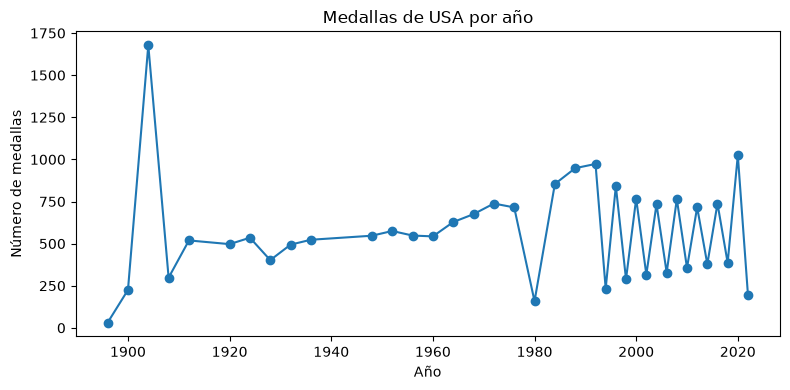

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(
    medallas_pais["Año"],
    medallas_pais["Medalla"],
    marker="o"
)
plt.title(f"Medallas de {pais} por año")
plt.xlabel("Año")
plt.ylabel("Número de medallas")
plt.tight_layout()
plt.show()

Para analizar la evolución temporal del medallero de USA, se agrupó el número de medallas por año y se ajustó una regresión lineal con linregress. La pendiente estimada fue positiva pero muy pequeña (0,5160), con un coeficiente de correlación 𝑅=0,0664 y un valor 𝑝=0,6961. Estos resultados indican que no existe una tendencia lineal estadísticamente significativa en la evolución de las medallas de USA a lo largo del tiempo. Aunque el gráfico muestra oscilaciones y algunos picos relevantes, la variabilidad entre ediciones es alta y no se observa un patrón lineal claro.

6. Chi-cuadrado NOC vs tipo de medalla

In [43]:
import pandas as pd
from scipy.stats import chi2_contingency

tabla_noc_medalla = pd.crosstab(
    data_new["NOC"],
    data_new["Medalla"]
)

chi2, pvalue, dof, esperados = chi2_contingency(tabla_noc_medalla)

print("Chi-cuadrado:", chi2)
print("p:", pvalue)
print("Grados de libertad:", dof)

Chi-cuadrado: 19303.450617875762
p: 0.0
Grados de libertad: 690


Eso significa que:

Sí hay asociación entre el país (NOC) y el tipo de medalla.

El valor p = 0.0 interpreta como extremadamente pequeño, prácticamente menor que cualquier umbral usual.

Por tanto, se rechaza la hipótesis nula de independencia.

En otras palabras, la distribución de Oro, Plata, Bronce y Ninguna varía según el país. La tabla mostrada para USA, FRA y GBR ya deja ver diferencias importantes en los conteos de cada categoría

In [44]:
tabla_noc_medalla.loc[["USA", "FRA", "GBR"]]

Medalla,Bronze,Gold,Ninguna,Silver
NOC,,,,
USA,1472,2717,15358,1806
FRA,737,589,12267,683
GBR,720,715,10971,764
